In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('train.csv')

In [4]:
df.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S
390,391,1,1,"Carter, Mr. William Ernest",male,36.0,1,2,113760,120.00,B96 B98,S
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.50,C82,C
865,866,1,2,"Bystrom, Mrs. (Karolina)",female,42.0,0,0,236852,13.00,NaN,S


In [5]:
df.shape
df.columns
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [19]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [18]:
df.drop(columns='Cabin',inplace=True)

KeyError: "['Cabin'] not found in axis"

In [20]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['Age'].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

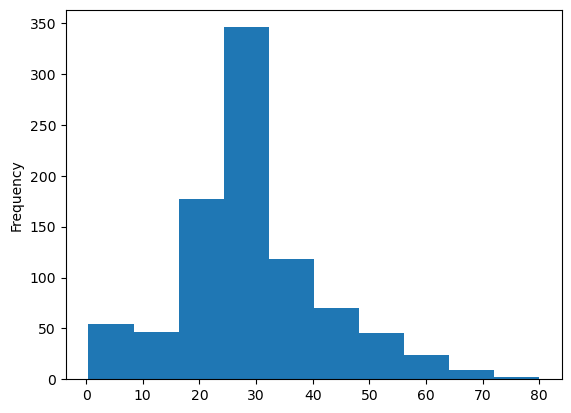

In [34]:
df['Age'].plot(kind='hist',bins=10)

In [35]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

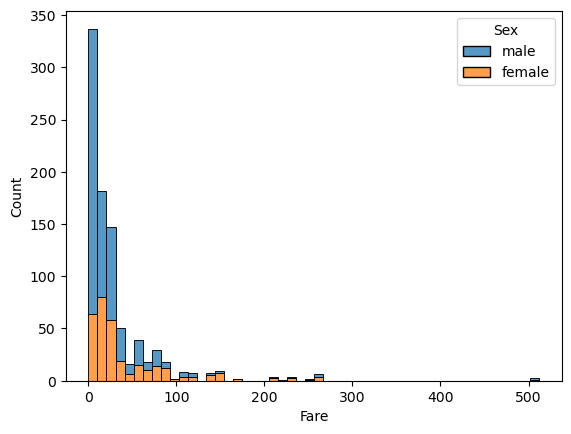

In [42]:
sns.histplot(x='Fare',data=df,hue='Sex',multiple='stack',bins=50)

<Axes: xlabel='Sex'>

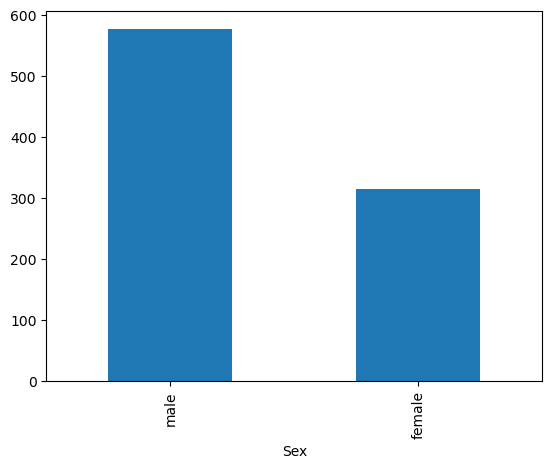

In [44]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: xlabel='Sex', ylabel='count'>

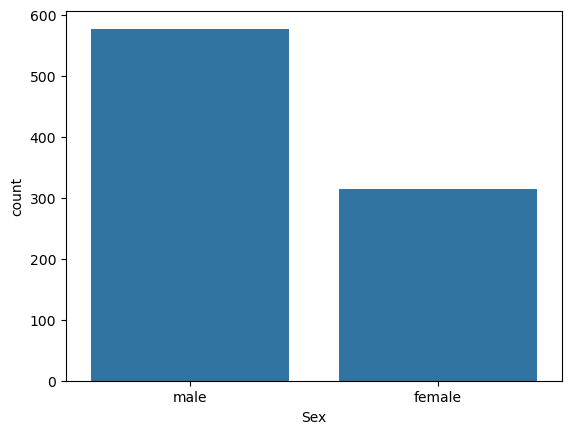

In [47]:
sns.countplot(x='Sex',data=df)

<Axes: xlabel='Survived', ylabel='count'>

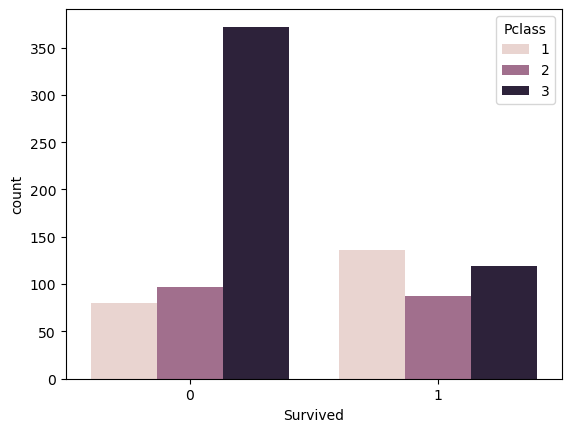

In [49]:
sns.countplot(x='Survived',data=df,hue='Pclass')

<Axes: xlabel='Fare', ylabel='Age'>

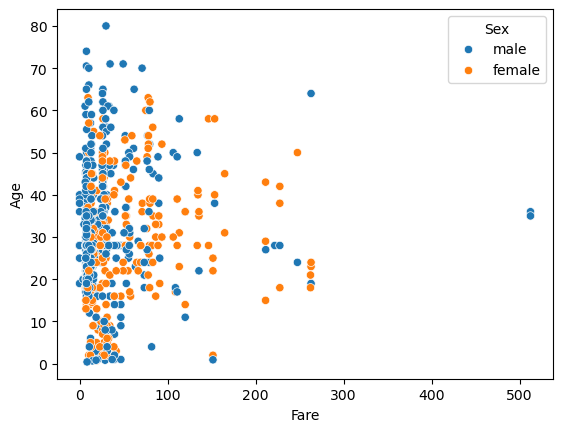

In [52]:
sns.scatterplot(x='Fare',y='Age',hue='Sex',data=df)

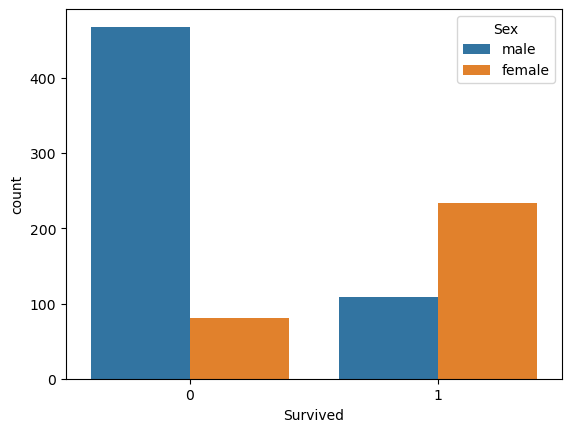

In [53]:
sns.countplot(
    x='Survived',
    hue='Sex',
    data=df
)

plt.show()

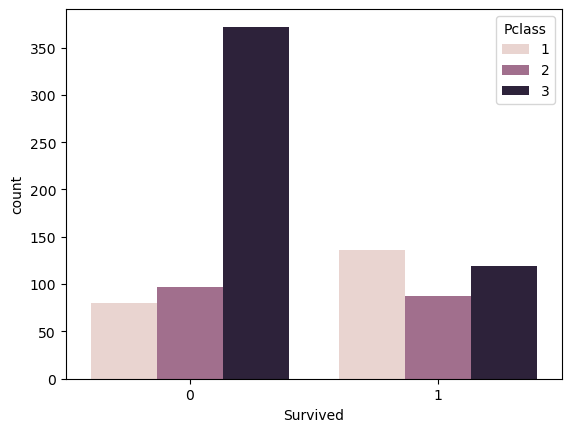

In [54]:
sns.countplot(
    x='Survived',
    hue='Pclass',
    data=df
)

plt.show()

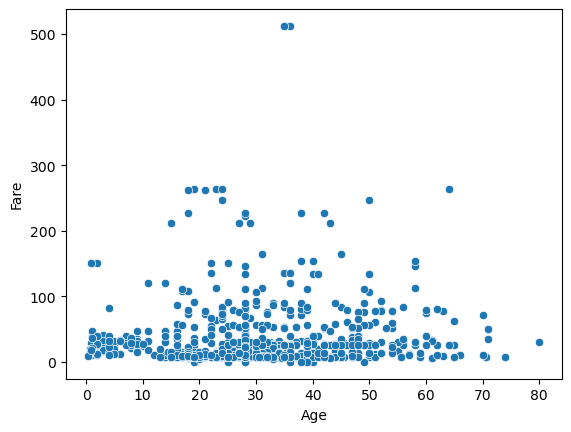

In [55]:
sns.scatterplot(
    x='Age',
    y='Fare',
    data=df
)

plt.show()

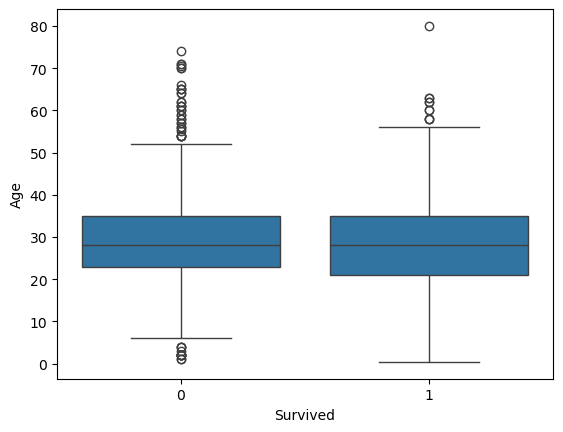

In [56]:
sns.boxplot(
    x='Survived',
    y='Age',
    data=df
)

plt.show()

<Axes: >

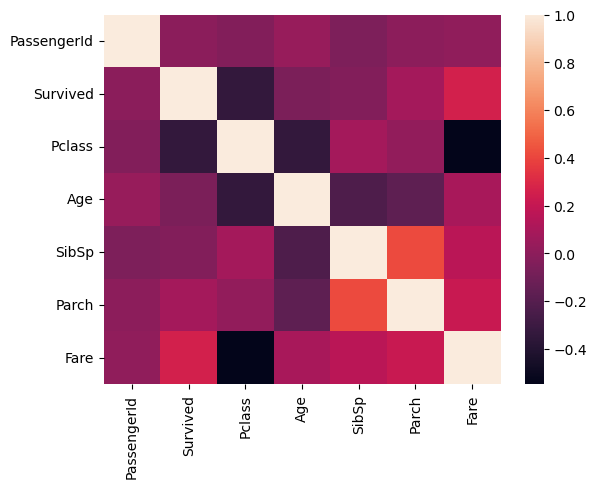

In [57]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr)

In [65]:
df.groupby('Sex')['Age'].mean()
df.groupby('Sex')['Age'].median()
# df.groupby('Sex')['Age'].mode()

Sex
female    28.0
male      28.0
Name: Age, dtype: float64

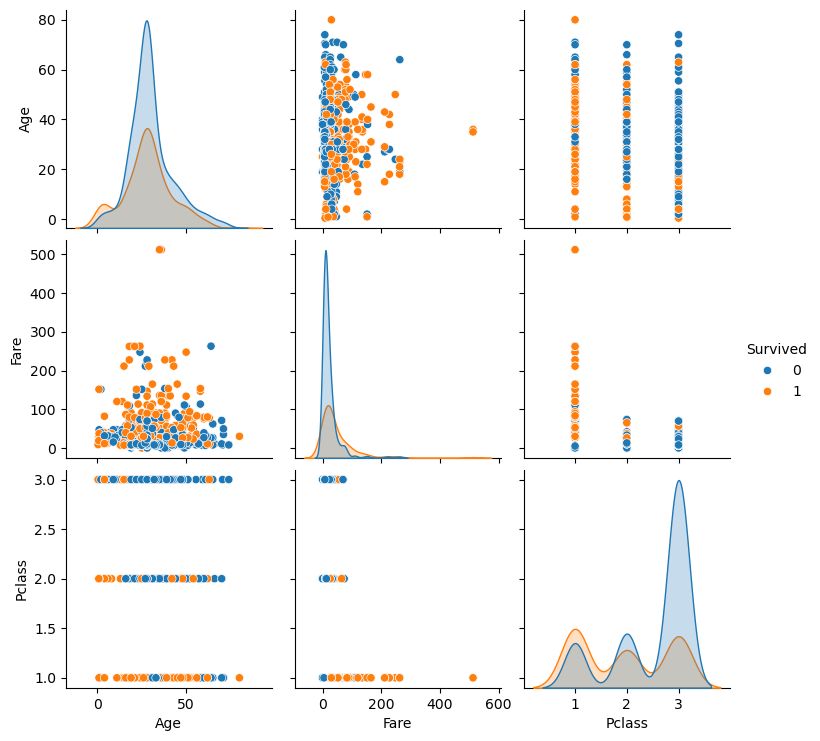

In [66]:
sns.pairplot(
    df[
        ['Age',
         'Fare',
         'Pclass',
         'Survived']
    ],
    hue='Survived'
)

In [69]:
df.pivot_table(values='Survived',index='Pclass',columns='Sex')

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [68]:
pd.crosstab(df['Sex'],df['Pclass'])

Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347
